
# Analysis of Norwegian Household Electricity Consumption Patterns

This notebook analyzes Norwegian household electricity consumption patterns to evaluate 
demand-side flexibility across different pricing regimes.

### Data Sources:
- **Household Consumption:** Hourly time-series data per bidding zone (https://elhub.no/data-og-innsikt/datakatalog).
- **Electricity Prices:** Hourly spot prices (Hva koster el)
- **Temperature:** Population-weighted mean temperature (ERA5 reanalysis), 
  spatially aggregated by bidding zone and Population data at 1 KM.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import warnings

# Suppress FutureWarnings to maintain clean output for production reports
warnings.filterwarnings("ignore", category=FutureWarning)

# Global visualization settings for academic/reporting standards
plt.rcParams.update({
    'axes.labelsize': 10,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'font.family': 'Arial'
})

# --- VISUAL IDENTITIES ---
# Maintain consistent color coding for the three regulatory regimes across all plots
period_palette = {
    'MonthlySubsidy': '#1f77b4', # Industry standard Blue
    'HourlySubsidy': '#ff7f0e',  # High-contrast Orange
    'Norgespris': '#2ca02c'      # 'Norgespris' Green
}

# Define zones (NO1-NO5) and a perceptually uniform color palette for mapping
zones = ['NO1', 'NO2', 'NO3', 'NO4', 'NO5']
zone_palette = sns.color_palette("viridis", n_colors=len(zones))

## 2. Data Loading & Regulatory Regime Categorization

This section prepares the dataset for analysis through three main steps:
1. **Temporal Alignment:** Localizing timestamps to UTC to ensure consistency across the five bidding zones.
2. **The "Natural Experiment" Framework:** Segmenting the timeline into three distinct regulatory regimes based on Norwegian government subsidy shifts:
    * **MonthlySubsidy:** Baseline period.
    * **HourlySubsidy:** Shift toward more granular price signals.
    * **NorgePrice:** The specific target pricing regime.
3. **Normalization:** Converting total zone consumption into `Consumption_per_household` to allow for valid cross-zone comparisons regardless of population density.

In [2]:
# Load raw time-series data
df = pd.read_csv("Data.csv", sep=",")

# Standardize temporal index to UTC for cross-zone alignment
df['start_date'] = pd.to_datetime(df['start_date'], utc=True)
df = df.set_index('start_date').sort_index()

# Quality Control: Remove records missing core variables
df = df.dropna(subset=['Price', 'Consumption'])

# --- 1. Define Policy Cutoffs (Natural Experiment Transitions) ---
# Transition from Monthly to Hourly subsidy
cutoff1 = pd.Timestamp("2023-09-01", tz="UTC") 
# Transition to NorgePrice regime
cutoff2 = pd.Timestamp("2025-10-01", tz="UTC") 

# --- 2. Labeling Regimes ---
# Categorize data points into their respective policy windows
conditions = [
    (df.index < cutoff1),
    (df.index >= cutoff1) & (df.index < cutoff2),
    (df.index >= cutoff2)
]
choices = ['MonthlySubsidy', 'HourlySubsidy', 'Norgespris']
df['Period'] = np.select(conditions, choices, default='Unknown')

# --- 3. Feature Engineering ---
# Normalize by household count to enable 'Apples-to-Apples' comparison between 
# high-population zones (NO1) and low-population zones (NO4).
df['Consumption_per_household'] = df['Consumption'] / df['NoMeasured']

# Backup processed state before performing aggregations
df_base = df.copy()

# --- 4. Validation Summary ---
print("Observation counts per regulatory regime:")
print(df['Period'].value_counts())


Observation counts per regulatory regime:
Period
HourlySubsidy     91320
MonthlySubsidy    72960
Norgespris        18120
Name: count, dtype: int64


### Norway Zone Map: Households, Population, and Population-Weighted Temperature
This figure was generated in a separate workbook and shows Norway divided into price areas (bidding zones), along with a snapshot of population density and a single-instance population-weighted temperature for 2025.
Population data at 1 km resolution were projected onto temperature data at roughly 9 km resolution and aggregated by zone. These projections were used to calculate the population-weighted temperature for each zone.


In [3]:
# Select the columns and rename
df_tail = df[['Zone', 'NoMeasured']].tail().rename(columns={'NoMeasured': 'No of Households'})
# Reset index so it does not display
df_tail = df_tail.reset_index(drop=True)
# Display as Markdown table (or in Jupyter it will render nicely)
print(df_tail.to_markdown(index=False))

| Zone   |   No of Households |
|:-------|-------------------:|
| NO1    |            1118075 |
| NO2    |             630506 |
| NO3    |             409408 |
| NO4    |             245962 |
| NO5    |             259421 |


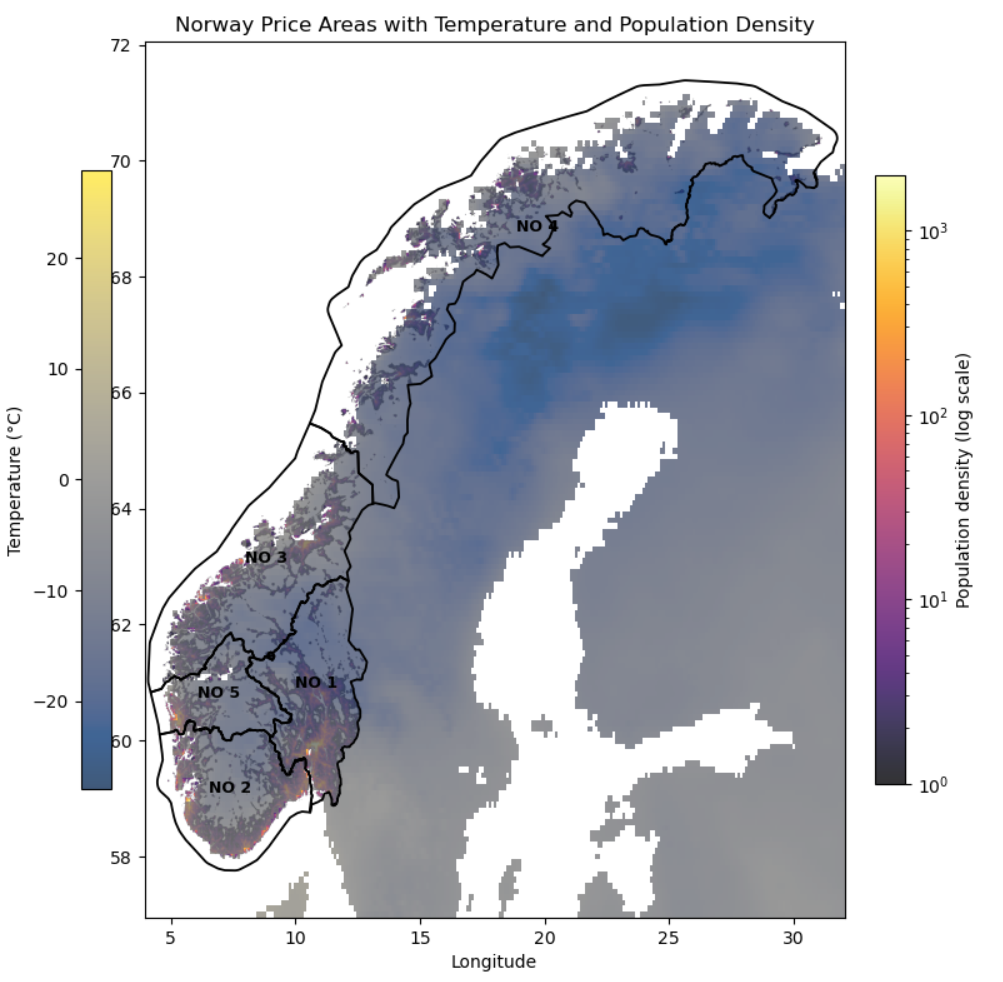

## 3. Exploratory Data Analysis (EDA): Zone-Specific Comparisons

To understand the underlying dynamics of the Norwegian electricity market, we compute zone-level descriptive statistics across the three regulatory regimes. This allows us to observe:
1. **Price Dispersion:** How average spot prices differ across bidding zones.
2. **Consumption Intensity:** Baseline household usage levels.
3. **Load Profiles:** Hourly and daily patterns that define the "shape" of Norwegian electricity demand.

*Note: This section identifies regional variations that will be controlled for in the subsequent regression models.*

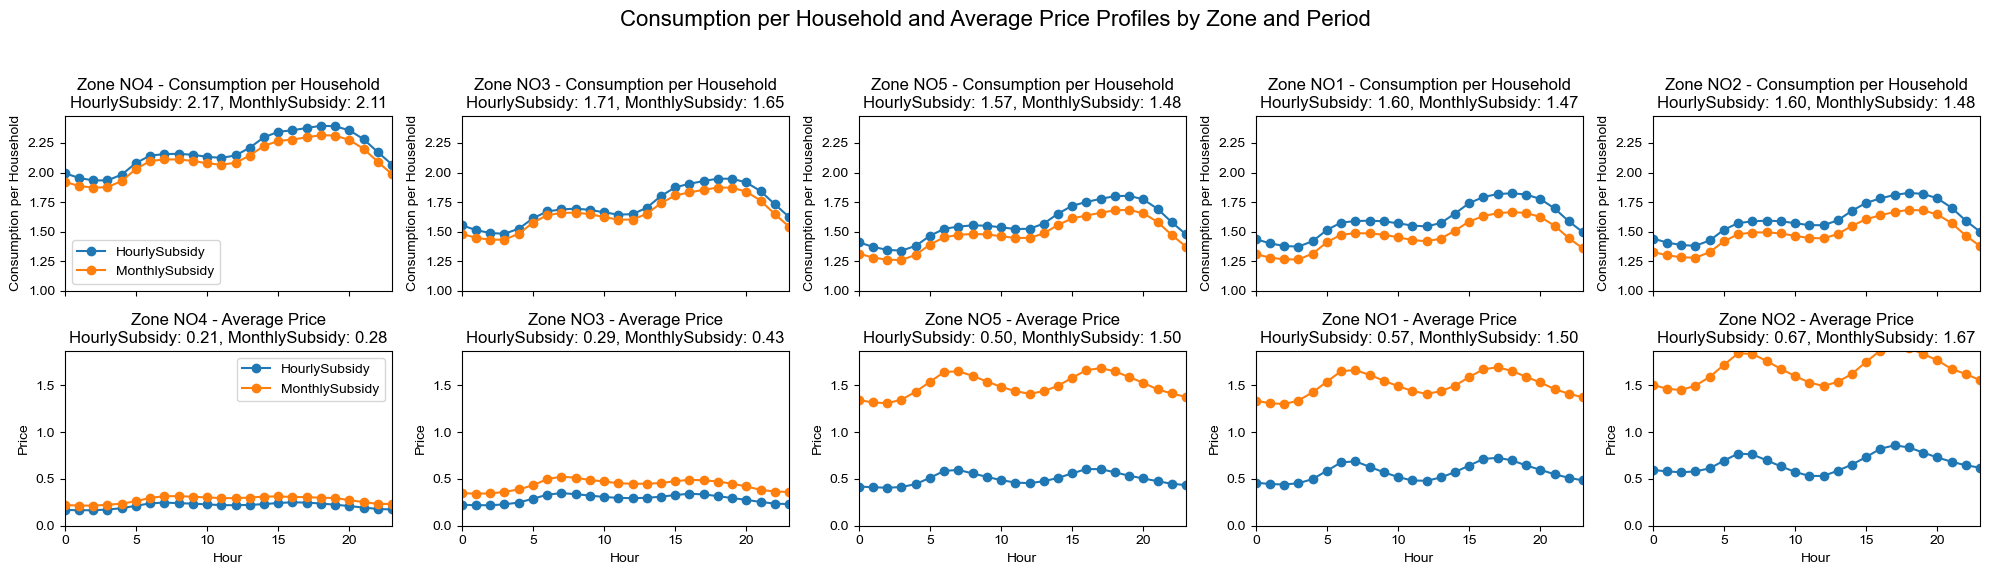

In [4]:
df=df_base[df_base.index < cutoff2]
df=df.copy()
df['hour'] = df.index.hour

periods = sorted(df['Period'].unique())
colors = sns.color_palette("tab10", n_colors=len(periods))

# Compute average price per zone (across all hours and periods)
zone_avg_price = df.groupby('Zone')['Price'].mean().sort_values()
zones_ordered = zone_avg_price.index.tolist()

# Determine y-axis limits for consistency
max_consumption = df.groupby(['Zone','hour'])['Consumption_per_household'].mean().max()
max_price = df.groupby(['Zone','hour'])['Price'].mean().max()

fig, axes = plt.subplots(2, len(zones_ordered), figsize=(4*len(zones_ordered), 6), sharex=True, sharey=False)
fig.suptitle('Consumption per Household and Average Price Profiles by Zone and Period', fontsize=16)

for col, zone in enumerate(zones_ordered):
    df_zone = df[df['Zone'] == zone]
    
    # Top row: Consumption per household
    ax1 = axes[0, col] if len(zones_ordered) > 1 else axes[0]
    means_consumption = []  # store mean for each period
    for i, period in enumerate(periods):
        df_period = df_zone[df_zone['Period'] == period]
        avg_consumption = df_period.groupby('hour')['Consumption_per_household'].mean()
        avg_consumption.plot(ax=ax1, label=period, color=colors[i], marker='o')
        means_consumption.append(f"{period}: {avg_consumption.mean():.2f}")
    
    # Display all-period means in the title
    ax1.set_title(f'Zone {zone} - Consumption per Household\n' + ', '.join(means_consumption))
    ax1.set_xlabel('Hour')
    ax1.set_ylabel('Consumption per Household')
    ax1.set_ylim(1, max_consumption*1.05)
    ax1.set_xlim(0,23)
    if col == 0:
        ax1.legend()
    
    # Bottom row: Average Price
    ax2 = axes[1, col] if len(zones_ordered) > 1 else axes[1]
    means_price = []  # store mean for each period
    for i, period in enumerate(periods):
        df_period = df_zone[df_zone['Period'] == period]
        avg_price = df_period.groupby('hour')['Price'].mean()
        avg_price.plot(ax=ax2, label=period, color=colors[i], marker='o')
        means_price.append(f"{period}: {avg_price.mean():.2f}")
    
    ax2.set_title(f'Zone {zone} - Average Price\n' + ', '.join(means_price))
    ax2.set_xlabel('Hour')
    ax2.set_ylabel('Price')
    ax2.set_ylim(0, max_price*1.4)
    ax2.set_xlim(0,23)
    if col == 0:
        ax2.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


The plot indicates that average consumption in low-price zones (NO4 and NO5) is higher than in high-price zones. However, this comparison may be misleading if temperature effects are not considered, since NO4 and NO5 also experience colder winters, which naturally drive higher electricity use.
Another pattern in the graph is that consumption across zones appears to increase when moving from a flat subsidy to an hourly subsidy — a period when electricity prices also fell significantly. Yet, this observation could also be misleading, as the first period (January 2022 to October 2023) may include colder winter months compared to the second period (October 2023 to July 2025).
To address this potential confounding factor, we can compare consumption patterns in summer and winter months separately.

## 4. Seasonal Variation: Winter vs. Summer Load Profiles
Given the high penetration of electric space heating in Norway, seasonality is a primary driver of demand. We categorize "Winter" (Nov–Mar) and "Summer" (May–Sept) to isolate the baseline behavioral shift from weather-driven peaks.

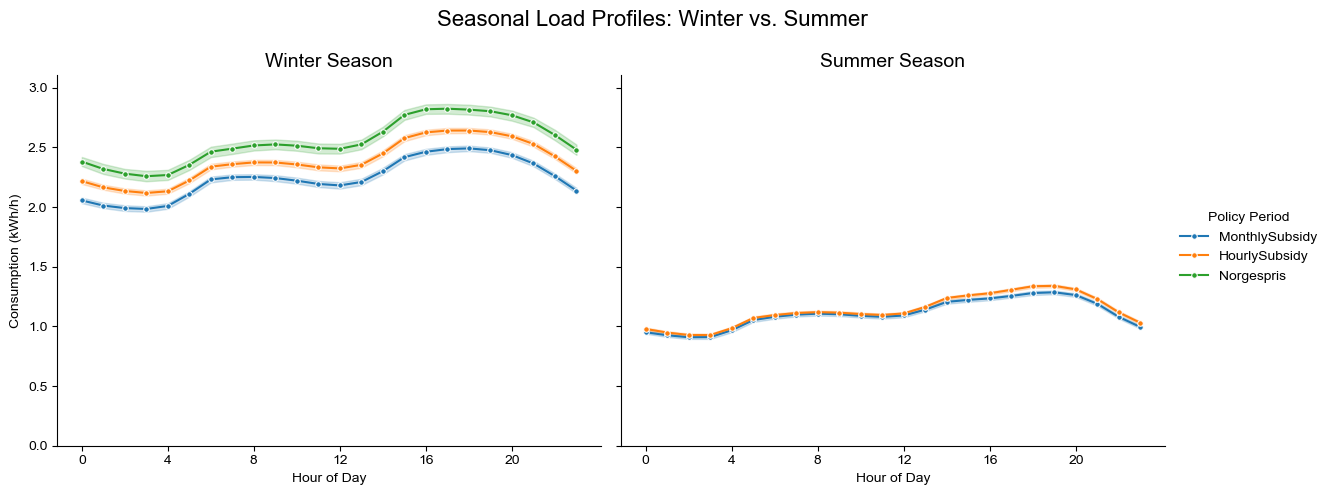

In [5]:
# 1. Define Seasons
# We exclude shoulder months (April, October) for a cleaner contrast
df_base['Month'] = df_base.index.month

conditions_season = [
    df_base['Month'].isin([11, 12, 1, 2, 3]),
    df_base['Month'].isin([5, 6, 7, 8, 9])
]
choices_season = ['Winter', 'Summer']

df_base['Season'] = np.select(conditions_season, choices_season, default='Shoulder')

# 2. Filtering for Analysis
df_season = df_base[df_base['Season'] != 'Shoulder'].copy()
df_season['hour'] = df_season.index.hour

# 3. Visualization
g = sns.FacetGrid(df_season, col="Season", hue="Period", 
                  palette=period_palette, height=5, aspect=1.2)

g.map(sns.lineplot, "hour", "Consumption_per_household", marker='o', markersize=4)

# Formatting
g.set_axis_labels("Hour of Day", "Consumption (kWh/h)")
g.set_titles("{col_name} Season", size=14)
g.add_legend(title="Policy Period")

# Standardize Y-axis across both plots for honest comparison
max_val = df_season.groupby(['Season', 'Period', 'hour'])['Consumption_per_household'].mean().max()
for ax in g.axes.flat:
    ax.set_ylim(0, max_val * 1.1)
    ax.set_xticks(range(0, 24, 4))

plt.subplots_adjust(top=0.85)
g.fig.suptitle('Seasonal Load Profiles: Winter vs. Summer', fontsize=16)
plt.show()

During the summer, mean consumption appears to be much more evenly distributed across the policy changes. Various factors, including temperature and the pace of electrification, influence the fluctuations in consumption levels. Based on these data, the theory that lower prices encourage overconsumption can neither be proven nor dismissed.
Notably, despite a price decrease, summer consumption has declined in some bidding zones and remained constant in others. Consequently, we will refrain from making further assumptions regarding absolute usage profiles; instead, the analysis will focus specifically on the dynamics of load shifting.

# 5. Core Analysis 

### Function: analyze_flatness

This function analyzes household electricity consumption “flatness” in relation to daily electricity price variation, stratified by zones, time periods, seasons, and weekends. It compares baseline days (low price variation) to high variation days, quantifying differences using statistical metrics such as coefficient of variation, peak-to-drought difference, and saved energy bill difference.

The main steps are:

- Copy and preprocess the input dataset, extracting date and hour.

- Calculate hourly consumption as a fraction of daily consumption per zone.

- Compute daily price variation (max − min price).

- Add season and weekend indicators.

- Stratify days into quartiles of price variation per zone, controlling for period, season, and weekend.

- Merge quartile labels back to the hourly dataset.

- Generate baseline and high variation hourly consumption profiles.

- Compute mean hourly prices for baseline and high variation days.

- Merge profiles for comparison and normalize them per zone.

- Calculate flatness metrics: CV_Diff, pd_Diff, and SEB_Diff.


The function returns a comparison table of hourly consumption fractions and prices, as well as a flatness metrics table. This helps assess whether higher price variability leads to flatter consumption patterns and estimates its impact on costs and demand response potential.

In [6]:

def analyze_flatness(df, plot=True):
    """
    Analyze consumption flatness vs. price variation with stratified quartiles.
    
    Parameters
    ----------
    df : pd.DataFrame
        Must have index as datetime and columns: ['Consumption','Price','Zone','Period'].
    plot : bool
        If True, produces zone-wise plots.
    
    Returns
    -------
    comparison : pd.DataFrame
        Hourly fractions and mean price patterns (baseline vs high-var).
    flatness_table : pd.DataFrame
        CV and entropy-based flatness metrics per Zone.
    """
    # -----------------------------
    # 1. Copy df and extract date/hour
    # -----------------------------
    df = df.copy()
    df['date'] = df.index.normalize()   # keeps datetime64[ns], not plain date
    df['hour'] = df.index.hour

    # -----------------------------
    # 2. Hourly fraction per day per zone
    # -----------------------------
    df['DailyTotal'] = df.groupby(['Zone','date'])['Consumption'].transform('sum')
    df['HourlyFraction'] = df['Consumption'] / df['DailyTotal']

    # -----------------------------
    # 3. Compute daily price diff
    # -----------------------------
    df_daily = df.groupby(['Zone','Period','date'])['Price'].agg(['max','min']).reset_index()
    df_daily['PriceDiff'] = df_daily['max'] - df_daily['min']

    # -----------------------------
    # 4. Add Season and Weekend flag
    # -----------------------------
    def get_season(month):
        if month in [12,1,2]:
            return 'Winter'
        elif month in [3,4,5]:
            return 'Spring'
        elif month in [6,7,8]:
            return 'Summer'
        else:
            return 'Autumn'

    df_daily['Season'] = df_daily['date'].dt.month.apply(get_season)
    df_daily['is_weekend'] = df_daily['date'].dt.dayofweek >= 5

    # -----------------------------
    # 5. Assign stratified quartiles per Zone (balanced by Period, Season, Weekend)
    # -----------------------------
    def assign_quartiles_per_zone(df_daily):
        result = []
        for zone, zone_df in df_daily.groupby('Zone'):
            zone_df['PriceVariationLevel'] = zone_df.groupby(['Period','Season','is_weekend'])['PriceDiff'] \
                                                    .transform(lambda x: pd.qcut(x, q=4, labels=['Low','Medium','High','VeryHigh']))
            result.append(zone_df)
        return pd.concat(result)

    df_daily = assign_quartiles_per_zone(df_daily)

    # -----------------------------
    # 6. Merge back to hourly df
    # -----------------------------
    df = df.merge(df_daily[['Zone','Period','date','PriceVariationLevel']], 
                  on=['Zone','Period','date'], how='left')

    # -----------------------------
    # 7. Baseline and high-var profiles
    # -----------------------------
    baseline = df[df['PriceVariationLevel']=='Low'].groupby(['Zone','hour'])['HourlyFraction'].mean().reset_index()
    baseline = baseline.rename(columns={'HourlyFraction':'BaselineFraction'})

    high_var = df[df['PriceVariationLevel']=='VeryHigh'].groupby(['Zone','hour'])['HourlyFraction'].mean().reset_index()
    high_var = high_var.rename(columns={'HourlyFraction':'HighVarFraction'})

    # -----------------------------
    # 8. Mean hourly price on baseline vs high-var days
    # -----------------------------
    mean_price_baseline = df[df['PriceVariationLevel']=='Low'].groupby(['Zone','hour'])['Price'].mean().reset_index()
    mean_price_baseline = mean_price_baseline.rename(columns={'Price':'MeanHourlyPrice_Baseline'})

    mean_price_high_var = df[df['PriceVariationLevel']=='VeryHigh'].groupby(['Zone','hour'])['Price'].mean().reset_index()
    mean_price_high_var = mean_price_high_var.rename(columns={'Price':'MeanHourlyPrice_HighVar'})

    # -----------------------------
    # 9. Merge for comparison
    # -----------------------------
    comparison = baseline.merge(high_var, on=['Zone','hour'])
    comparison = comparison.merge(mean_price_baseline, on=['Zone','hour'])
    comparison = comparison.merge(mean_price_high_var, on=['Zone','hour'])

    # -----------------------------
    # 10. Normalize all curves per zone
    # -----------------------------
    zones = comparison['Zone'].unique()
    for zone in zones:
        mask = comparison['Zone'] == zone
        for col in ['BaselineFraction','HighVarFraction']:
            comparison.loc[mask, col] /= comparison.loc[mask, col].sum()

    # -----------------------------
    # 11. Compute flatness metrics
    # -----------------------------
        def pd_metric(p):
            return np.max(p) - np.min(p)
    
        flatness_results = []
        for zone in zones:
            subset = comparison[comparison['Zone'] == zone]
            baseline_frac = subset['BaselineFraction']
            highvar_frac = subset['HighVarFraction']

            cv_baseline = subset['BaselineFraction'].std() / subset['BaselineFraction'].mean()
            cv_highvar = subset['HighVarFraction'].std() / subset['HighVarFraction'].mean()
        
            seb_baseline = baseline_frac*subset['MeanHourlyPrice_HighVar'] * 3000/ subset['MeanHourlyPrice_HighVar'].sum()*24

            seb_highvar = highvar_frac*subset['MeanHourlyPrice_HighVar'] * 3000/ subset['MeanHourlyPrice_HighVar'].sum()*24

            # SME diff : sum over hours
            seb_diff = (seb_baseline-seb_highvar).sum()

            pd_baseline = pd_metric(subset['BaselineFraction'])
            pd_highvar = pd_metric(subset['HighVarFraction'])
        
        
            flatness_results.append({
                "Zone": zone,
                "CV_Diff": cv_baseline- cv_highvar ,
                "pd_Diff": (pd_baseline - pd_highvar) / pd_baseline * 100  ,
                "SEB_Diff": seb_diff,

            })
        
    flatness_table = pd.DataFrame(flatness_results)

    # -----------------------------
    # 12. Plots
    # -----------------------------
    if plot:
        for zone in zones:
            plt.figure(figsize=(12,6))
            sns.lineplot(data=comparison[comparison['Zone']==zone], x='hour', y='BaselineFraction', label='Baseline Fraction')
            sns.lineplot(data=comparison[comparison['Zone']==zone], x='hour', y='HighVarFraction', label='High-Var Fraction')
            plt.title(f'Zone {zone}: Normalized Hourly Patterns (Consumption & Price)')
            plt.xlabel('Hour of Day')
            plt.ylabel('Normalized Value (sum=1 per zone)')
            plt.grid(True)
            plt.legend()
            plt.show()

    return comparison, flatness_table, df


### Analysis of Multiple Periods

This function runs analyze_flatness() on multiple datasets corresponding to different periods, and then aggregates the results for comparison. It produces a combined dataset of hourly consumption fractions and price patterns, as well as a combined table of flatness metrics across all periods. Additionally, it generates a grid of plots comparing baseline and high variation profiles for each zone and period.

Main steps:

- Loop over each dataset and period label.

- Run analyze_flatness() on each dataset without plotting.

- Append period labels to the resulting comparison and flatness tables.

- Concatenate results from all periods into combined comparison and flatness dataframes.

- Create a grid plot showing baseline and high variation consumption profiles for each zone and period.

Outputs:

- combined_comparison: Table of hourly consumption fractions and mean price patterns across all periods.

- combined_flatness: Table of flatness metrics across all periods.


In [7]:
def analyze_multiple_periods(dfs, period_labels, plot=True):


    all_comparisons = []
    all_flatness = []
    all_tables = []

    # Loop over periods
    for df, period in zip(dfs, period_labels):
        comp, flat, tabs = analyze_flatness(df, plot=False)
        comp['Period'] = period
        flat['Period'] = period
        all_comparisons.append(comp)
        all_flatness.append(flat)
        all_tables.append(tabs)

    combined_comparison = pd.concat(all_comparisons, ignore_index=True)
    combined_flatness = pd.concat(all_flatness, ignore_index=True)
    combined_tables = pd.concat(all_tables, ignore_index=True)

    # -----------------------------
    # Plot: zones × periods (grid)
    # -----------------------------
    if plot:
        zones = combined_comparison['Zone'].unique()
        periods = period_labels

        fig, axes = plt.subplots(len(zones), len(periods), figsize=(8, 8), sharey=True)
        if len(zones) == 1:
            axes = np.array([axes])  # ensure 2D array
        if len(periods) == 1:
            axes = axes[:, np.newaxis]

        for i, zone in enumerate(zones):
            for j, period in enumerate(periods):
                subset = combined_comparison[
                    (combined_comparison['Zone'] == zone) &
                    (combined_comparison['Period'] == period)
                ]
                ax = axes[i, j]
                ax.plot(subset['hour'], subset['BaselineFraction'], label='Baseline', color='blue')
                ax.plot(subset['hour'], subset['HighVarFraction'], label='HighVar', color='orange')
                ax.set_title(f"Zone {zone} – {period}")
                ax.set_xlabel("Hour")
                ax.grid(True)
                if i == 0 and j == len(periods) - 1:
                    ax.legend()

        fig.supylabel("Normalized Values", fontsize=10, fontfamily="Arial")
        plt.tight_layout()
        fig.savefig("hourly_fractions_plot.png", dpi=300)
        plt.show()

    return combined_comparison, combined_flatness, combined_tables


In [8]:
def visualize_flatness(flatness_all):
    """
    Visualize changes in flatness metrics (CV_Diff and Entropy_Diff) per Zone × Period.
    
    Parameters
    ----------

    """

    plt.rcParams.update({
    'axes.labelsize': 10,       # Axis labels
    'axes.titlesize': 12,       # Titles
    'xtick.labelsize': 10,      # X tick labels
    'ytick.labelsize': 10,      # Y tick labels
    'legend.fontsize': 10,      # Legend text
    'font.family': 'Arial'      # Font family
})
    # --- Heatmaps ---
    pivot_cv = flatness_all.pivot(index='Zone', columns='Period', values='CV_Diff')
    pivot_entropy = flatness_all.pivot(index='Zone', columns='Period', values='pd_Diff')

    plt.figure(figsize=(8,5))
    sns.heatmap(pivot_cv, annot=True, fmt=".3f", cmap="coolwarm", center=0)
    plt.title("CV Difference (Baseline-HighVar)")
    plt.show()

    plt.figure(figsize=(8,5))
    sns.heatmap(pivot_entropy, annot=True, fmt=".3f", cmap="coolwarm", center=0)
    plt.title("P/T Difference (Baseline-HighVar) in %")
    plt.show()
    
      # --- Grouped Bar Charts ---
    fig, axes = plt.subplots(2, 1, figsize=(8,4), sharex=True)
    
    # Top plot
    sns.barplot(data=flatness_all, x='Zone', y='CV_Diff', hue='Period', ax=axes[0])
    axes[0].axhline(0, color='k', linestyle='--')
    axes[0].set_ylabel(r'$\Delta CV \,\, (-)$')
    axes[0].set_title("Change in CV \n between days with extreme hourly price variability and days with normal variability")
    
    # Middle plot
    sns.barplot(data=flatness_all, x='Zone', y='pd_Diff', hue='Period', ax=axes[1])
    axes[1].axhline(0, color='k', linestyle='--')
    axes[1].set_ylabel(r'$\Delta P/T \, (\%)$')
    title_str =  (
    r'Percentage change of $\Delta P/T$'
    '\nbetween days with extreme hourly price variability and days with normal variability')

    axes[1].set_title(title_str)

    
    # Remove legends from both axes
    axes[0].get_legend().remove()
    axes[1].get_legend().remove()
    #axes[2].get_legend().remove()
    
    # Add a single shared legend outside the plots
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05),
               ncol=len(labels), frameon=False)
    
    plt.tight_layout()
    fig.savefig("Metrics_plot.png", dpi=300, bbox_inches="tight")
    plt.show()

    plt.show()

### Visualisation of Hourly Consumption Fractions And Flatness

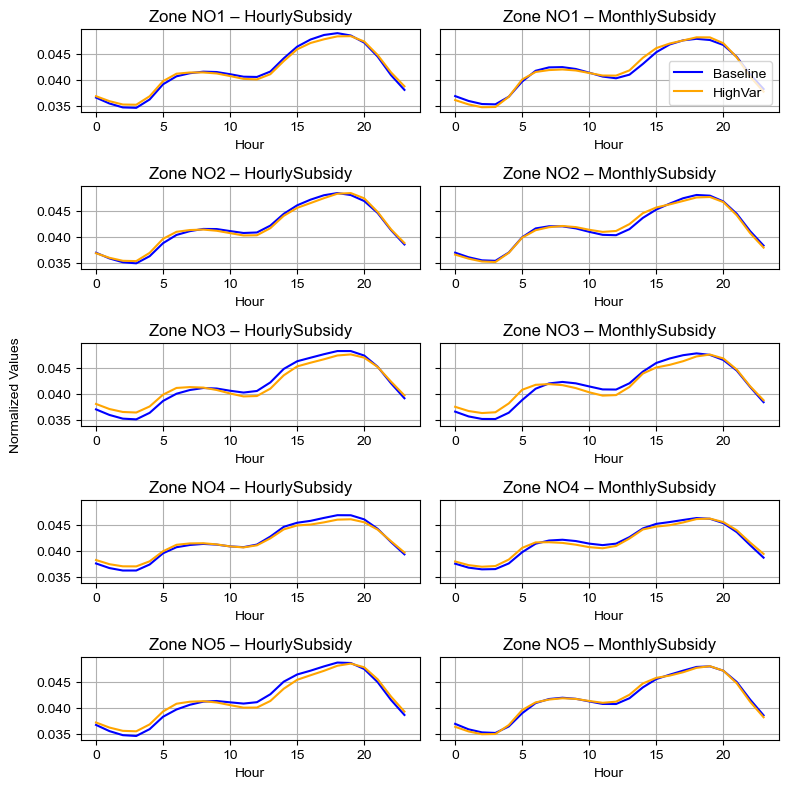

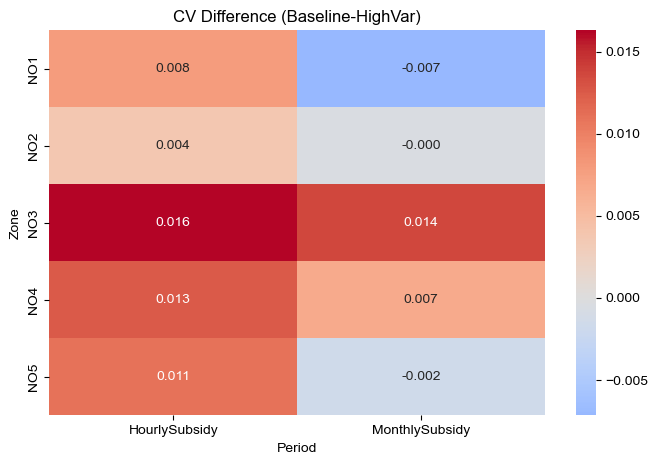

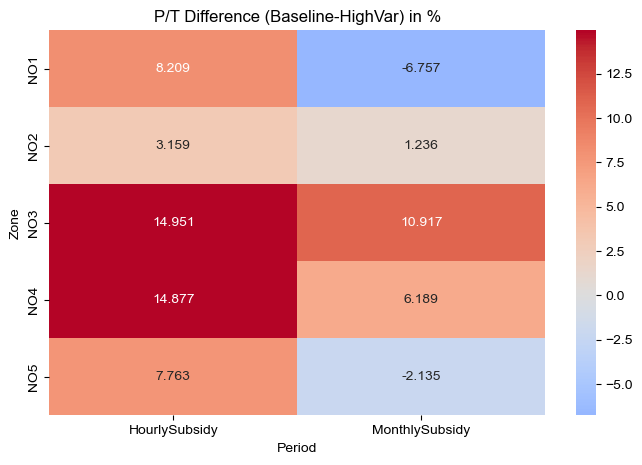

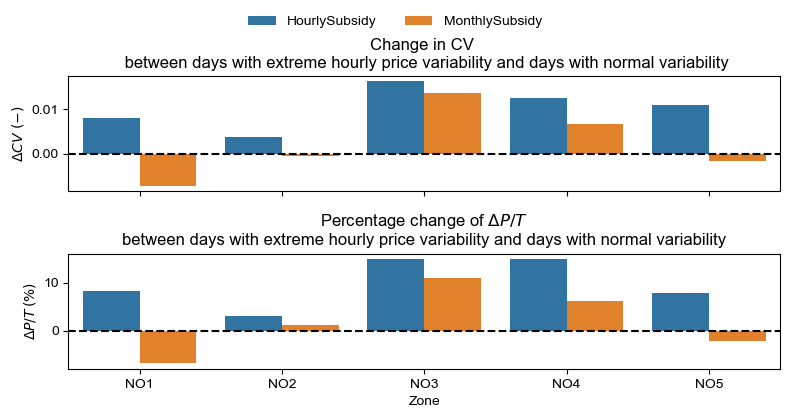

In [9]:

# Get unique periods
a = np.unique(df.Period)

# Create a list of dataframes, one for each period
dfs = [df.loc[df.Period == period] for period in a]

# Labels are just the unique periods
labels = list(a)


comparison_all, flatness_all, tables_all = analyze_multiple_periods(dfs, labels)

visualize_flatness(flatness_all)


### SEB Calculation (Baseline: Monthly Subsidy Period)
This section establishes the reference profile using the **Monthly Subsidy** period to determine the Saved Energy Bill (SME), as utilized in the final paper.

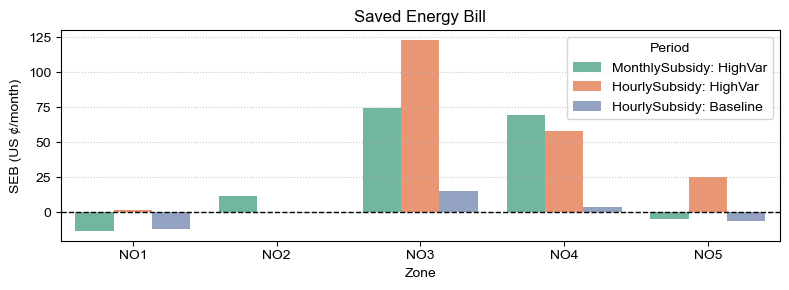

In [10]:
results = []

for zone, zone_group in comparison_all.groupby("Zone"):
    # Baseline: MonthlySubsidy
    baseline_group = zone_group[zone_group["Period"] == "MonthlySubsidy"]
    hours = baseline_group["hour"].values
    
    # --- Curve 1: Baseline Monthly profile × Normalized Monthly price ---
    baseline= baseline_group["BaselineFraction"].values  

    
    # --- Curve 2: HighVar Monthly profile × Monthly price ---
    diff_monthly = (baseline- baseline_group["HighVarFraction"].values) * baseline_group["MeanHourlyPrice_HighVar"].values/baseline_group["MeanHourlyPrice_HighVar"].values.sum()*240*100*30
    
    
    # --- Curve 3: HighVar Hourly profile × Hourly price ---
    hourly_group = zone_group[zone_group["Period"] == "HourlySubsidy"]

    
    diff_hourly_profile = (baseline-hourly_group["HighVarFraction"].values ) * hourly_group["MeanHourlyPrice_HighVar"].values/hourly_group["MeanHourlyPrice_HighVar"].values.sum()*240 *100*30
    
    # --- Curve 4: Baseline Hourly profile × Hourly price ---
    diff_hourly_base = (baseline-hourly_group["BaselineFraction"].values) * hourly_group["MeanHourlyPrice_Baseline"].values/hourly_group["MeanHourlyPrice_Baseline"].values.sum()*240*100*30

    
    
    results.append({
        "Zone": zone,
        "MonthlySubsidy: HighVar": diff_monthly.sum(),
        "HourlySubsidy: HighVar": diff_hourly_profile.sum(),
        "HourlySubsidy: Baseline" :diff_hourly_base.sum(),
    })

# Results summary
results_df = pd.DataFrame(results)

plt.figure(figsize=(8,3))

# Melt DataFrame to long format
df_melted = results_df.melt(id_vars="Zone", 
                             value_vars=["MonthlySubsidy: HighVar", "HourlySubsidy: HighVar", "HourlySubsidy: Baseline"],
                             var_name="Metric", value_name="Value")

# Grouped bar plot
sns.barplot(data=df_melted, x="Zone", y="Value", hue="Metric", palette='Set2')

plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.title('Saved Energy Bill')
plt.ylabel(r'SEB (US ¢/month)')
plt.xlabel('Zone')
plt.legend(title='Period')
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig("SEB.png", dpi=300)  # save as PNG

plt.show()



## 5. Methodology: Constructing a Fair Comparison (Stratified Volatility)

To measure how households respond to price signals, we compare days with **Low Price Volatility** (our Baseline) against days with **Very High Price Volatility**. However, a simple ranking of price differences would be biased by factors like winter heating demand or regional market structures.

To ensure the results are scientifically valid, we implement a **Stratified Quartile Approach**. This ensures that the "Quartile" divisions you see in the following charts are consistent and rigorously balanced.

### The Logic of Stratification
Every day in our dataset is assigned a volatility rank from Low to Very High. To ensure a "like-for-like" comparison, this ranking is performed independently within specific "buckets":

* **By Bidding Zone (NO1–NO5):** We account for the structural differences in regional power markets (e.g., comparing Oslo to Tromsø).
* **By Regulatory Period:** We ensure that transitions in government subsidy models are analyzed within their own policy context.
* **By Seasonality:** A "High Volatility" day in Summer is defined relative to other Summer days. This prevents extreme Winter price spreads from dominating the entire dataset.
* **By Day Type (Weekday vs. Weekend):** We separate these to account for the natural differences in household routines and industrial base loads.

### Validating the Distribution (The Visuals Below)
The following visualizations serve as a "health check" for this stratification process:

* **Price Levels & Variation:** The box plots and heatmaps confirm that days labeled "Very High" actually represent significantly different price environments than "Low" days, even after controlling for the zone and period.
* **Temporal Consistency:** The bar charts demonstrate how many "Low" vs. "Very High" days were identified during Weekends and across different Seasons (Winter vs. Summer).

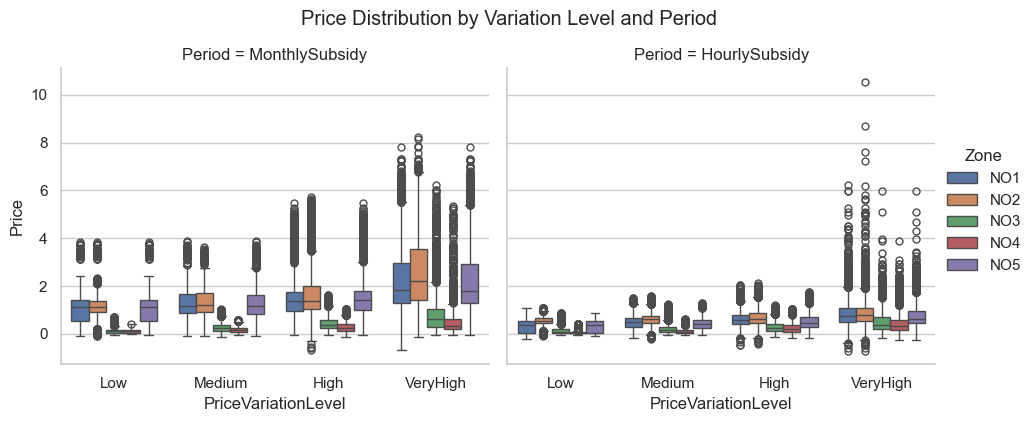

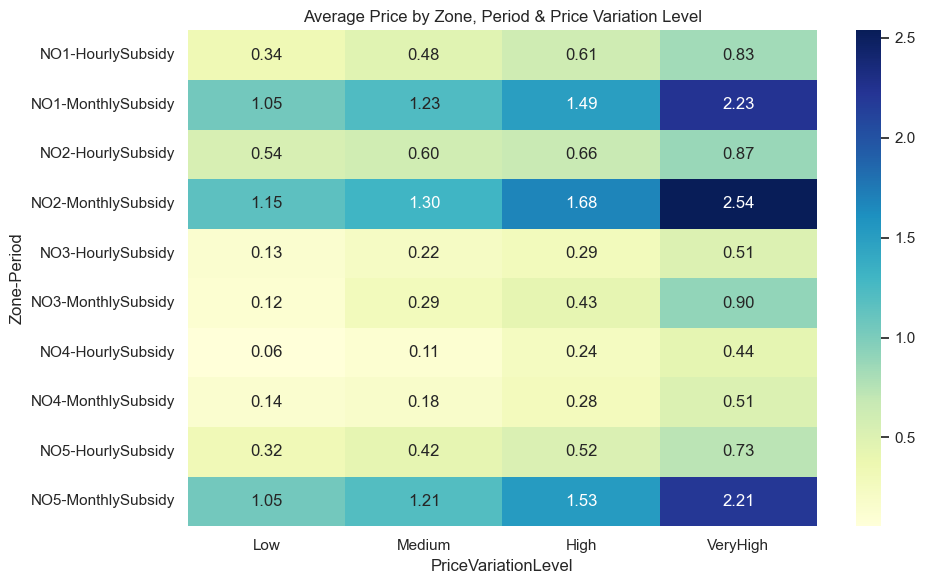

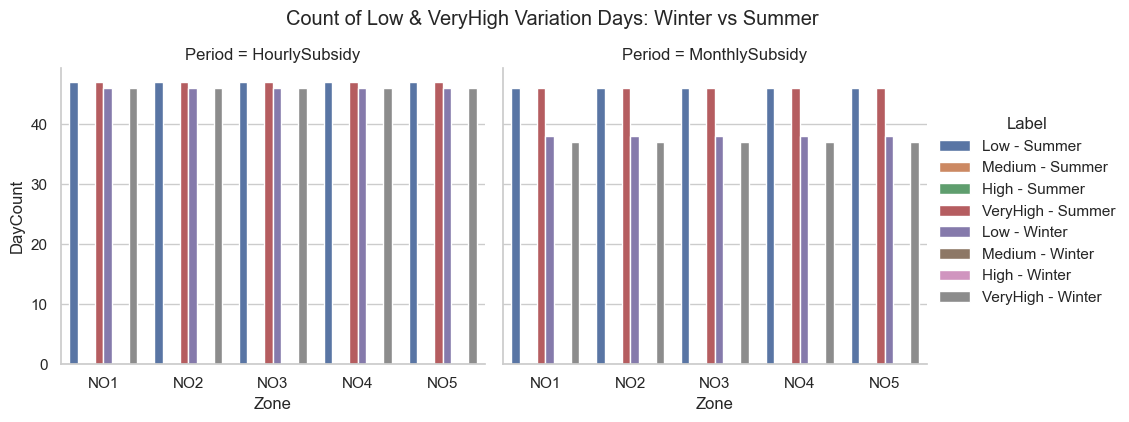

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Setup and Feature Engineering
# ---------------------------
A = df.copy()
A['date'] = A.index.normalize()
A['hour'] = A.index.hour
A['month'] = A.index.month

# Efficiently calculate hourly fraction using vectorized operations
A['DailyTotal'] = A.groupby(['Zone', 'date'])['Consumption'].transform('sum')
A['HourlyFraction'] = A['Consumption'] / A['DailyTotal']

# 2. Daily Aggregation & Categorization
# ---------------------------
# Vectorized season mapping
season_map = {
    'Winter': [12, 1, 2],
    'Spring': [3, 4, 5],
    'Summer': [6, 7, 8],
    'Autumn': [9, 10, 11]
}
month_to_season = {m: s for s, months in season_map.items() for m in months}

# Aggregate daily stats
A_daily = A.groupby(['Zone', 'Period', 'date']).agg(
    Price_Max=('Price', 'max'),
    Price_Min=('Price', 'min')
).reset_index()

A_daily['PriceDiff'] = A_daily['Price_Max'] - A_daily['Price_Min']
A_daily['Season'] = A_daily['date'].dt.month.map(month_to_season)
A_daily['is_weekend'] = A_daily['date'].dt.dayofweek >= 5

# 3. Stratified Quartiles
# ---------------------------
# Assign quartiles stratified by Zone, Period, Season, and Weekend status
A_daily['PriceVariationLevel'] = (
    A_daily.groupby(['Zone', 'Period', 'Season', 'is_weekend'])['PriceDiff']
    .transform(lambda x: pd.qcut(x, q=4, labels=['Low', 'Medium', 'High', 'VeryHigh']) 
               if len(x.unique()) >= 4 else 'Medium') 
)

# Merge back into original hourly data
A = A.merge(
    A_daily[['Zone', 'Period', 'date', 'PriceVariationLevel', 'Season', 'is_weekend']], 
    on=['Zone', 'Period', 'date'], 
    how='left'
)

# 4. Visualizations
# ---------------------------
sns.set_theme(style="whitegrid")

# Plot 1: Price Distributions
g1 = sns.catplot(
    data=A, x="PriceVariationLevel", y="Price", hue="Zone",
    kind="box", col="Period", col_wrap=2, height=4, aspect=1.2
)
g1.fig.suptitle("Price Distribution by Variation Level and Period", y=1.05)

# Plot 2: Heatmap of Average Prices
pivot_table = A.pivot_table(
    index=['Zone', 'Period'], 
    columns='PriceVariationLevel', 
    values='Price', 
    aggfunc='mean'
)
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Average Price by Zone, Period & Price Variation Level")
plt.tight_layout()

# Plot 3: Seasonality & Weekend Validation
# Filtering for focal points (Low and VeryHigh) in specific seasons
focus_mask = (A['PriceVariationLevel'].isin(['Low', 'VeryHigh'])) & \
             (A['Season'].isin(['Winter', 'Summer']))

# Count unique days efficiently
season_counts = (
    A[focus_mask].groupby(['Zone', 'Period', 'Season', 'PriceVariationLevel'])['date']
    .nunique()
    .reset_index(name='DayCount')
)

# FIXED: Convert Categorical to String to avoid TypeError during concatenation
season_counts['Label'] = (
    season_counts['PriceVariationLevel'].astype(str) + 
    " - " + 
    season_counts['Season'].astype(str)
)

g2 = sns.catplot(
    data=season_counts, x='Zone', y='DayCount', hue='Label',
    col='Period', kind='bar', height=4, aspect=1.2
)
g2.fig.suptitle("Count of Low & VeryHigh Variation Days: Winter vs Summer", y=1.05)

plt.show()

## Plot Used to Explain Method of calculating SEB (in Method Section) 
This plot filters one Zone (NO5) and one period (Hourly Subsidy), uses the original analysis and makes a plot. 

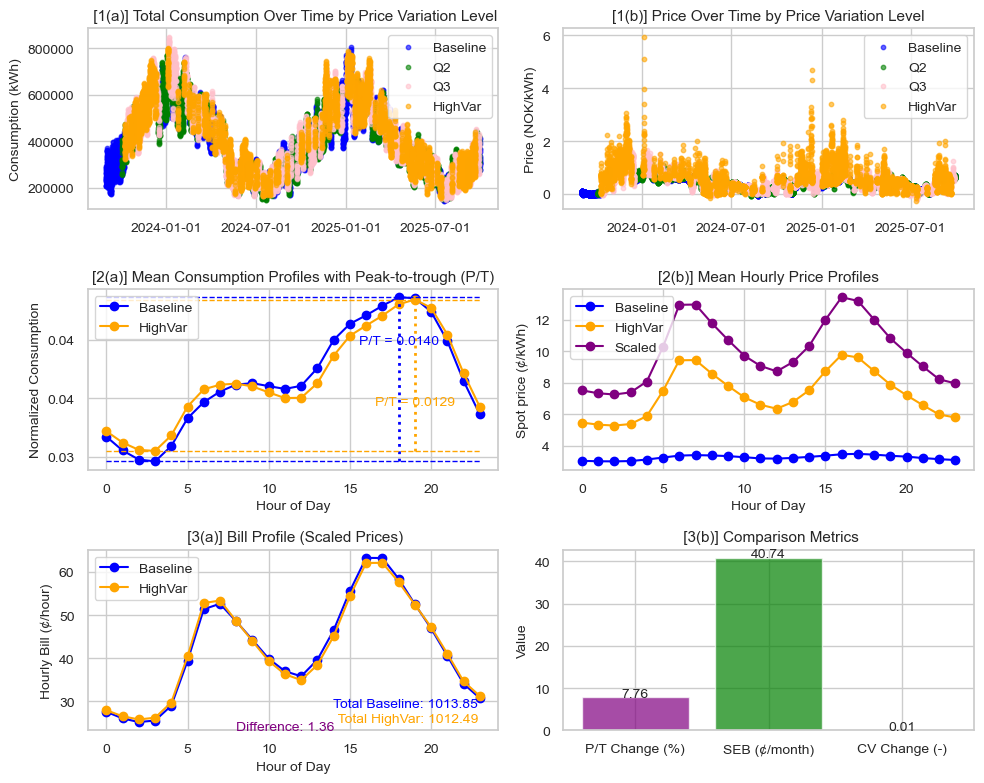

In [12]:
comparison_all, flatness_all, alltabs = analyze_multiple_periods(dfs, labels,plot=False)

f_df = comparison_all[
    (comparison_all['Period'] == "HourlySubsidy") &
    (comparison_all['Zone'] == "NO5")
]


T_df=alltabs[
    (alltabs['Period'] == "HourlySubsidy") &
    (alltabs['Zone'] == "NO5")
]

def plot_pd_subplot(f_df, T_df):
    """
    Plot:
    - Row 1: Continuous Consumption and Price colored by PriceVariationLevel
    - Row 2: Baseline & HighVar Fraction with P/D
    - Row 3: Hourly Bills using HighVar prices, PD change % and SEB
    """

    sns.set(style="whitegrid")
    plt.rcParams.update({
    'axes.labelsize': 10,       # Axis labels
    'axes.titlesize': 11,       # Titles
    'xtick.labelsize': 10,      # X tick labels
    'ytick.labelsize': 10,      # Y tick labels
    'legend.fontsize': 10,      # Legend text
    'font.family': 'Arial'      # Font family
})
    
    fig, axes = plt.subplots(3, 2, figsize=(10, 8), gridspec_kw={'height_ratios': [1, 1, 1]})



    # Define palette with renamed levels
    palette = {
        "Low": "blue",        
        "Medium": "green",
        "High": "pink",     
        "VeryHigh": "orange"
    }

    # Name mapping for legend display
    name_mapping = {
        "Low": "Baseline",
        "Medium": "Q2",
        "High": "Q3",
        "VeryHigh": "HighVar"
    }

    # =========================
    # ROW 1, COL 1: Consumption time series colored by PriceVariationLevel
    # =========================
    ax0 = axes[0, 0]
    for level, color in palette.items():
        subset = T_df[T_df['PriceVariationLevel'] == level]
        ax0.scatter(subset['date'], subset['Consumption'], color=color, label=name_mapping.get(level, level), s=10,alpha=0.6)

    ax0.set_title(" [1(a)] Total Consumption Over Time by Price Variation Level")
    ax0.set_ylabel("Consumption (kWh)")
    ax0.grid(True)

    ax0.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=6))
    ax0.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    ax0.legend(title=None)

    # =========================
    # ROW 1, COL 2: Price time series colored by PriceVariationLevel
    # =========================
    ax1 = axes[0, 1]
    for level, color in palette.items():
        subset = T_df[T_df['PriceVariationLevel'] == level]
        ax1.scatter(subset['date'], subset['Price'], color=color, label=name_mapping.get(level, level), s=10,alpha=0.6)



    
    ax1.set_title("[1(b)] Price Over Time by Price Variation Level")
    ax1.set_ylabel("Price (NOK/kWh)")
    ax1.grid(True)

    ax1.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=6))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    ax1.legend(title=None)

    # =========================
    # ROW 2, COL 1: Baseline & HighVar Fraction with P/D
    # =========================
    ax2 = axes[1, 0]
    ax2.plot(f_df['hour'], f_df['BaselineFraction'], label="Baseline", color="blue", marker="o")
    ax2.plot(f_df['hour'], f_df['HighVarFraction'], label="HighVar", color="orange", marker="o")

    ax2.set_title("[2(a)] Mean Consumption Profiles with Peak-to-trough (P/T)")
    ax2.set_xlabel("Hour of Day")
    ax2.set_ylabel("Normalized Consumption")
    ax2.legend()

    ax2.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))  # ← Two decimal places

    baseline_max = f_df['BaselineFraction'].max()
    baseline_min = f_df['BaselineFraction'].min()
    highvar_max = f_df['HighVarFraction'].max()
    highvar_min = f_df['HighVarFraction'].min()

    pd_baseline = baseline_max - baseline_min
    pd_highvar = highvar_max - highvar_min

    cv_baseline = f_df['BaselineFraction'].std() / f_df['BaselineFraction'].mean()
    cv_highvar = f_df['HighVarFraction'].std() / f_df['HighVarFraction'].mean()

    ax2.hlines(y=baseline_max, xmin=0, xmax=23, colors="blue", linestyles="dashed", linewidth=1)
    ax2.hlines(y=baseline_min, xmin=0, xmax=23, colors="blue", linestyles="dashed", linewidth=1)
    ax2.vlines(x=f_df['hour'][f_df['BaselineFraction'].idxmax()],
               ymin=baseline_min, ymax=baseline_max,
               colors="blue", linestyles="dotted", linewidth=2)
    ax2.text(f_df['hour'][f_df['BaselineFraction'].idxmax()], baseline_max - 0.004,
             f"P/T = {pd_baseline:.4f}", color="blue", fontsize=10, ha="center")

    ax2.hlines(y=highvar_max, xmin=0, xmax=23, colors="orange", linestyles="dashed", linewidth=1)
    ax2.hlines(y=highvar_min, xmin=0, xmax=23, colors="orange", linestyles="dashed", linewidth=1)
    ax2.vlines(x=f_df['hour'][f_df['HighVarFraction'].idxmax()],
               ymin=highvar_min, ymax=highvar_max,
               colors="orange", linestyles="dotted", linewidth=2)
    ax2.text(f_df['hour'][f_df['HighVarFraction'].idxmax()], highvar_max - 0.009,
             f"P/T = {pd_highvar:.4f}", color="orange", fontsize=10, ha="center")

    # =========================
    # ROW 2, COL 2: Mean Hourly Prices
    # =========================
    ax3 = axes[1, 1]
    ax3.plot(f_df['hour'], f_df['MeanHourlyPrice_Baseline']*10, label="Baseline", color="blue", marker="o")
    ax3.plot(f_df['hour'], f_df['MeanHourlyPrice_HighVar']*10, label="HighVar", color="orange", marker="o")
    ax3.plot(f_df['hour'], f_df['MeanHourlyPrice_HighVar']*10/f_df['MeanHourlyPrice_HighVar'].sum()*24, label="Scaled", color="purple", marker="o")

    ax3.set_title("[2(b)] Mean Hourly Price Profiles")
    ax3.set_xlabel("Hour of Day")
    ax3.set_ylabel("Spot price (¢/kWh)")
    ax3.legend()

    # =========================
    # ROW 3, COL 1: Hourly Bills using HighVar prices
    # =========================
    ax4 = axes[2, 0]
    price_scale = f_df['MeanHourlyPrice_HighVar'].sum()
    baseline_bill = f_df['BaselineFraction'] * f_df['MeanHourlyPrice_HighVar'] / price_scale * 240*100
    highvar_bill = f_df['HighVarFraction'] * f_df['MeanHourlyPrice_HighVar'] / price_scale * 240*100

    ax4.plot(f_df['hour'], baseline_bill, label="Baseline", color="blue", marker="o")
    ax4.plot(f_df['hour'], highvar_bill, label="HighVar", color="orange", marker="o")

    baseline_total = baseline_bill.sum()
    highvar_total = highvar_bill.sum()

    ax4.text(0.95, 0.18, f"Total Baseline: {baseline_total:.2f}", transform=ax4.transAxes,
             fontsize=10, color="blue", ha="right", va="top")
    ax4.text(0.95, 0.1, f" Total HighVar: {highvar_total:.2f}", transform=ax4.transAxes,
             fontsize=10, color="orange", ha="right", va="top")
    ax4.text(0.6, 0.05, f"Difference: {baseline_total-highvar_total:.2f}", transform=ax4.transAxes,
             fontsize=10, color="purple", ha="right", va="top")

    ax4.set_title(" [3(a)] Bill Profile (Scaled Prices)")
    ax4.set_xlabel("Hour of Day")
    ax4.set_ylabel("Hourly Bill (¢/hour)")
    ax4.legend(loc="upper left")  # ← Legend top left

    # =========================
    # ROW 3, COL 2: PD change % and SEB
    # =========================
    ax5 = axes[2, 1]
    pd_change_percent = (pd_baseline - pd_highvar) / pd_baseline
    cv_change = cv_baseline - cv_highvar
    seb = (baseline_bill - highvar_bill).sum() * 30

    ax5.bar(["P/T Change (%)"], [pd_change_percent*100], color="purple", alpha=0.7)
    ax5.bar(["SEB"], [seb], color="green", alpha=0.7)
    ax5.bar(["CV Change"], [cv_change], color="blue", alpha=0.7)

    for i, v in enumerate([pd_change_percent*100, seb, cv_change]):
        ax5.text(i, v + 0.01*abs(v), f"{v:.2f}", ha="center", fontsize=10)

    ax5.set_title(" [3(b)] Comparison Metrics")
    ax5.set_ylabel("Value")
    ax5.set_xticks([0, 1, 2])
    ax5.set_xticklabels(["P/T Change (%)", "SEB (¢/month)", "CV Change (-)"])
    plt.tight_layout()
    plt.savefig("Method.png", dpi=300, bbox_inches="tight")

    plt.show()
plot_pd_subplot(f_df, T_df)

# Additional Analysis and Comparison with Norgespris Period
The methodology used to analyze shifts between quartiles in previous sections does not apply to the NorgePrice regime, as prices are fixed under this model. To compare the three subsidy periods fairly, an alternative analytical approach is required. This shift in method is also necessary due to the more limited data currently available for the NorgePrice period compared to the historical datasets.

Norgespris is an ongoing voluntary scheme and has not been adopted by all households. In zones with historically low electricity prices, the economic incentive to switch is limited. By contrast, for Zones 1, 2, and 5—where historical prices have been nearly two to three times the flat rate offered by the Norgespris scheme—switching would have been an obvious economic choice. The graph below shows the percentage of households enrolled in the scheme.



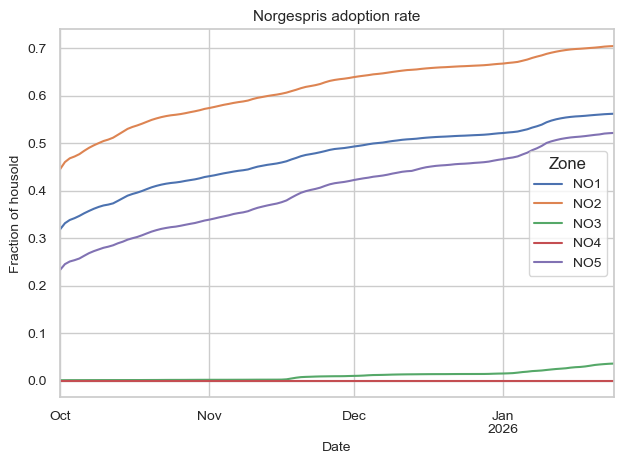

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Read and filter
A = (
    pd.read_csv("NorgeCount.csv", sep=";")
      .query("FORBRUKSGRUPPE == 'Husholdning'")
      .assign(Fraction=lambda df: df.ANTALL_NORGESPRIS / df.ANTALL,
              DATO=lambda df: pd.to_datetime(df.DATO))
      .set_index('DATO')
)

# Plot
plt.figure()
for zone, g in A.groupby('PRISOMRÅDE'):
    g['Fraction'].plot(label=zone)

plt.xlabel('Date')
plt.ylabel('Fraction of housold')
plt.title('Norgespris adoption rate')
plt.legend(title='Zone')
plt.tight_layout()
plt.show()

In [14]:

df_Norge = df_base[df_base.index.month.isin([10,11,12,1,2])]
df_Norge = df_Norge.copy()  # make a safe copy
df_Norge.loc[:, 'date'] = df_Norge.index.date
df_Norge.loc[:, 'year'] = df_Norge.index.year
df_Norge.loc[:, 'month'] = df_Norge.index.month
df_Norge.loc[:, 'hour'] = df_Norge.index.hour


# Plot for Normalized consumption and PD change 
This graphic compares the normalized consumption for three subsidy periods (only winter months). This is not included in the paper.


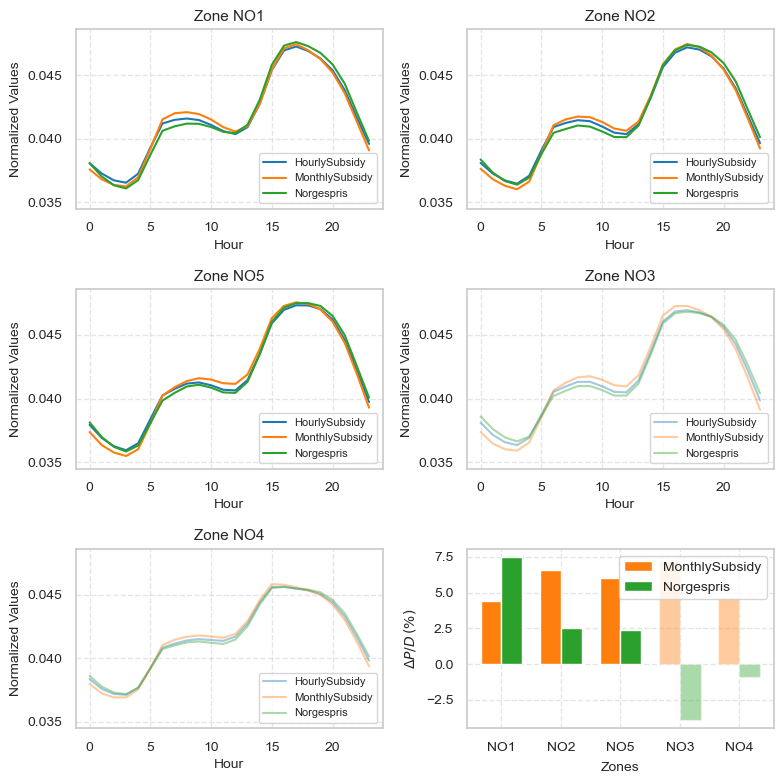

In [15]:
# --- Compute HourlyFraction per day, per period separately ---
Fractions_list = []

for period in df_Norge['Period'] .unique():
    df_period = df_Norge[df_Norge['Period'] == period].copy()

    # Daily total only for this period
    df_period['DailyTotal'] = df_period.groupby(['Zone','date'])['Consumption_per_household'].transform('sum')
    df_period['HourlyFraction'] = df_period['Consumption_per_household'] / df_period['DailyTotal']

    Fractions_list.append(df_period)

# Combine all periods back
Fractions = pd.concat(Fractions_list)

# --- Compute mean hourly fraction across days for each Zone × Period × hour ---
Fractions_mean = (
    Fractions.groupby(['Zone','Period','hour'])['HourlyFraction']
             .mean()
             .reset_index()
)

# --- Verify sum = 1 ---
sum_check = Fractions_mean.groupby(['Zone','Period'])['HourlyFraction'].sum().reset_index(name='SumCheck')
#print(sum_check)




# --- Configuration ---
important_zones = ['NO1','NO2','NO5']
other_zones = ['NO3','NO4']
all_zones = important_zones + other_zones
periods = sorted(Fractions_mean['Period'].unique())
baseline_period = 'HourlySubsidy'
plot_periods = [p for p in periods if p != baseline_period]  # periods other than baseline

# Colors for periods (same for line plots and bars)
period_colors = {
    periods[0]: 'tab:blue',
    periods[1]: 'tab:orange',
    periods[2]: 'tab:green'
}

# --- Figure setup ---
fig, axes = plt.subplots(3, 2, figsize=(8, 8))
axes = axes.flatten()

# --- Determine common Y-axis limits for subplots 1–5 ---
ymin = Fractions_mean['HourlyFraction'].min()
ymax = Fractions_mean['HourlyFraction'].max()
y_padding = 0.001
ymin -= y_padding
ymax += y_padding

# --- Subplots 1 to 5: Line plots ---
for idx, zone in enumerate(all_zones[:5]):
    ax = axes[idx]
    zone_data = Fractions_mean[Fractions_mean['Zone'] == zone]
    
    for period in periods:
        p_data = zone_data[zone_data['Period'] == period]
        alpha_val = 1.0 if zone in important_zones else 0.4
        ax.plot(p_data['hour'], p_data['HourlyFraction'], label=period, 
                alpha=alpha_val, color=period_colors[period])
    
    ax.set_title(f"Zone {zone}")
    
    # X-axis ticks
    xticks = [0, 5, 10, 15, 20]
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks)
    
    # Force same Y-axis across all 5 subplots
    ax.set_ylim(ymin, ymax)
    ax.set_yticks(np.linspace(ymin, ymax, 3))  # 3 evenly spaced ticks
    ax.set_ylim(ymin, ymax)
    ax.set_yticks([0.035,0.040,0.045])  # 3 evenly spaced ticks
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))  # show 3 digits

    
    ax.set_xlabel('Hour')
    ax.set_ylabel('Normalized Values')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(title='', fontsize=8, loc='lower right')

# --- 6th subplot: Bar plot of % change vs HourlySubsidy ---
ax = axes[5]

# Prepare percentage change data
pct_changes = []
for zone in all_zones:
    zone_data = Fractions_mean[Fractions_mean['Zone'] == zone]
    
    # PD baseline
    PD_base = zone_data[zone_data['Period'] == baseline_period]['HourlyFraction'].max() - \
              zone_data[zone_data['Period'] == baseline_period]['HourlyFraction'].min()

    # PD % change for other periods
    pct_list = []
    for period in plot_periods:
        PD = zone_data[zone_data['Period'] == period]['HourlyFraction'].max() - \
             zone_data[zone_data['Period'] == period]['HourlyFraction'].min()
        pct = 100 * (PD - PD_base) / PD_base if PD_base != 0 else 0
        pct_list.append(pct)
    pct_changes.append(pct_list)

pct_changes = np.array(pct_changes)  # shape: (5 zones, 2 periods)
x = np.arange(len(all_zones))
bar_width = 0.35

# Plot bars per period using same color as line plots
for i, period in enumerate(plot_periods):
    for j, zone in enumerate(all_zones):
        alpha_val = 1.0 if zone in important_zones else 0.4
        ax.bar(x[j] + i*bar_width, pct_changes[j, i], width=bar_width,
               label=period if j==0 else "", 
               alpha=alpha_val, color=period_colors[period])

# X and Y labels for 6th subplot
ax.set_xticks(x + bar_width*(len(plot_periods)-1)/2)
ax.set_xticklabels(all_zones)
ax.set_xlabel('Zones', fontsize=10, labelpad=6)
ax.set_ylabel(r'$\Delta P/D \, (\%)$', fontsize=10, labelpad=6)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(title='', fontsize=10, loc='upper right')
plt.tight_layout()
fig.savefig("Hr_con_No.png", dpi=300)
plt.show()

# Plot for CV and P/T change in comparison to the Hourly Subsidy period (used in Paper)


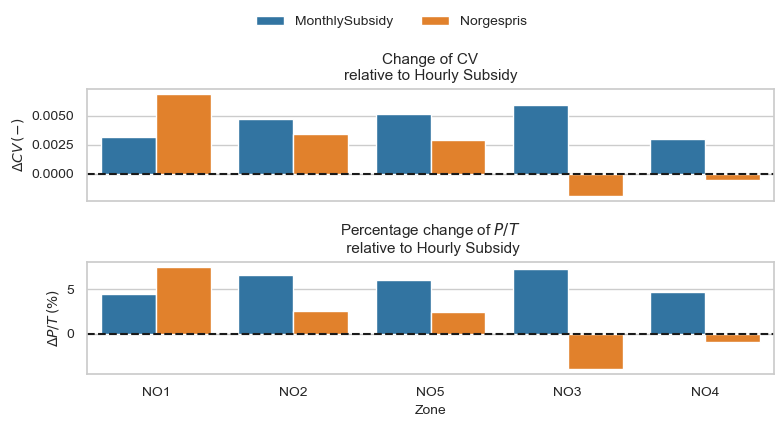

In [16]:
# --- Compute PD and CV percentage changes relative to baseline ---

pd_changes = []
cv_changes = []

for zone in all_zones:
    zone_data = Fractions_mean[Fractions_mean['Zone'] == zone]
    
    # --- Baseline profile ---
    base_profile = zone_data[zone_data['Period'] == baseline_period]['HourlyFraction']
    
    PD_base = base_profile.max() - base_profile.min()
    CV_base = base_profile.std() / base_profile.mean()
    
    pd_list = []
    cv_list = []
    
    for period in plot_periods:
        profile = zone_data[zone_data['Period'] == period]['HourlyFraction']
        
        # PD
        PD = profile.max() - profile.min()
        pd_pct = 100 * (PD - PD_base) / PD_base if PD_base != 0 else 0
        pd_list.append(pd_pct)
        
        # CV
        CV = profile.std() / profile.mean()
        cv = (CV - CV_base)
        cv_list.append(cv)
    
    pd_changes.append(pd_list)
    cv_changes.append(cv_list)

pd_changes = np.array(pd_changes)
cv_changes = np.array(cv_changes)

# --- Build dataframe for seaborn grouped bars ---

rows = []
for i, zone in enumerate(all_zones):
    for j, period in enumerate(plot_periods):
        rows.append({
            "Zone": zone,
            "Period": period,
            "CV_Diff": cv_changes[i, j],
            "pd_Diff": pd_changes[i, j]
        })

metrics_df = pd.DataFrame(rows)

import seaborn as sns
import matplotlib.pyplot as plt

# Define colors for the hue levels (blue and orange)
palette_colors = ["#1f77b4", "#ff7f0e"]  # default Matplotlib blue and orange

# --- Grouped Bar Charts ---
fig, axes = plt.subplots(2, 1, figsize=(8, 4), sharex=True)

# --- Top plot: CV change ---
sns.barplot(
    data=metrics_df,
    x='Zone',
    y='CV_Diff',
    hue='Period',
    palette=palette_colors,
    ax=axes[0]
)

axes[0].axhline(0, color='k', linestyle='--')
axes[0].set_ylabel(r'$\Delta CV \, (-)$')
axes[0].set_title("Change of CV\nrelative to Hourly Subsidy")

# --- Bottom plot: PD change ---
sns.barplot(
    data=metrics_df,
    x='Zone',
    y='pd_Diff',
    hue='Period',
    palette=palette_colors,
    ax=axes[1]
)

axes[1].axhline(0, color='k', linestyle='--')
axes[1].set_ylabel(r'$\Delta P/T \, (\%)$')


title_str =  (
    r'Percentage change of $P/T$'
    '\n relative to Hourly Subsidy')

axes[1].set_title( title_str )

# --- Remove legends from axes ---
axes[0].get_legend().remove()
axes[1].get_legend().remove()

# --- Add single shared legend ---
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.08),
    ncol=len(labels),
    frameon=False
)
plt.tight_layout()
fig.savefig("PD_CV_changes2.png", dpi=300, bbox_inches="tight")
plt.show()

# Plot of absolute consumption profiles and population-weighted mean outdoor temperatures for all subsidy periods (winter Months)

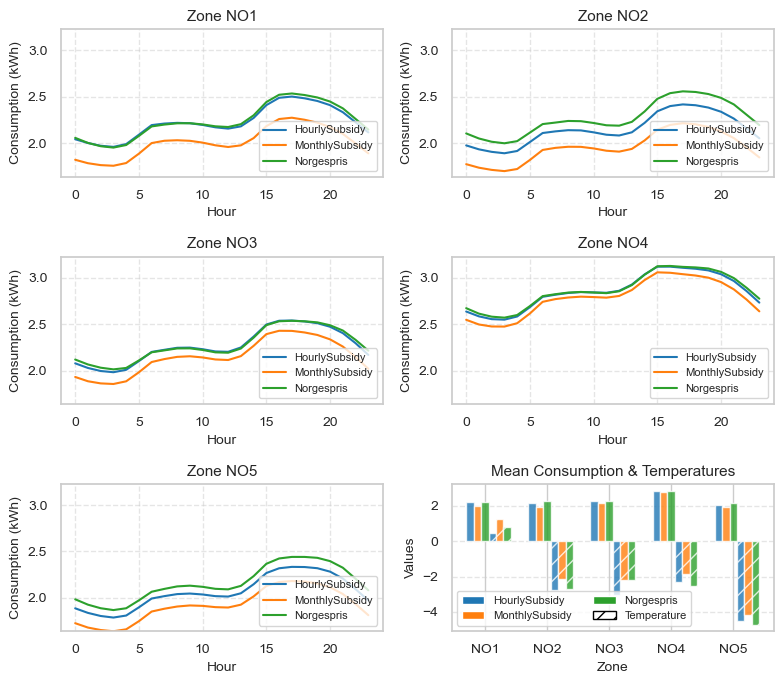

In [17]:

hourly_avg = (
    df_Norge
    .groupby(['Zone', 'Period', 'hour'])[['Consumption_per_household', 'MeanTemp']]
    .mean()
    .reset_index()
)

zones = sorted(hourly_avg['Zone'].unique())
periods = sorted(hourly_avg['Period'].unique())
hour_ticks = [0, 5, 10, 15, 20]

important_zones = zones[:5]  # for line plots
period_colors = {
    periods[0]: 'tab:blue',
    periods[1]: 'tab:orange',
    periods[2]: 'tab:green'
}

# --- 3x2 grid ---
fig, axes = plt.subplots(3, 2, figsize=(8,7))
axes = axes.flatten()

# --- Step 1: Line plots for first 5 zones ---
ymin = hourly_avg['Consumption_per_household'].min()
ymax = hourly_avg['Consumption_per_household'].max()+0.1

for idx, zone in enumerate(important_zones):
    ax = axes[idx]
    zone_data = hourly_avg[hourly_avg['Zone'] == zone]
    
    for period in periods:
        p_data = zone_data[zone_data['Period'] == period]
        ax.plot(
            p_data['hour'],
            p_data['Consumption_per_household'],
            label=period,
            color=period_colors[period]
        )

    ax.set_title(f"Zone {zone}")
    ax.set_xticks(hour_ticks)
    ax.set_xlabel('Hour')
    ax.set_ylabel('Consumption (kWh)')
    ax.set_ylim(ymin, ymax)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(fontsize=8, loc='lower right')

ax_bar = axes[5]

# Compute means per zone per period
zone_period_means = (
    hourly_avg
    .groupby(['Zone', 'Period'])[['Consumption_per_household', 'MeanTemp']]
    .mean()
    .unstack(level=1)
)

x = np.arange(len(zones))
bar_width = 0.12  # width to fit 6 bars per zone

# Plot bars: shift positions for 6 bars per zone
for i, period in enumerate(periods):
    # Consumption bars (solid)
    ax_bar.bar(
        x - bar_width*2 + i*bar_width,
        zone_period_means['Consumption_per_household'][period].values,
        width=bar_width,
        color=period_colors[period],
        alpha=0.8
    )
    # Temperature bars (pattern)
    ax_bar.bar(
        x + bar_width + i*bar_width,
        zone_period_means['MeanTemp'][period].values,
        width=bar_width,
        color=period_colors[period],
        alpha=0.8,
        hatch='//'
    )

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(zones)
ax_bar.set_xlabel('Zone')
ax_bar.set_ylabel('Values')
ax_bar.set_title('Mean Consumption & Temperatures')
ax_bar.grid(axis='y', linestyle='--', alpha=0.5)

# --- Legend: two columns ---
from matplotlib.patches import Patch

# Period colors for legend
period_legend = [Patch(facecolor=period_colors[period], label=period) for period in periods]
# Pattern legend for consumption vs temperature
pattern_legend = [
    Patch(facecolor='white', edgecolor='black', hatch='//', label='Temperature')
]

# Combine legends and make 2 columns
ax_bar.legend(handles=period_legend + pattern_legend, fontsize=8, loc='lower left', ncol=2)
plt.tight_layout()
fig.savefig("Ab_con_No.png", dpi=300)

plt.show()


# Econometric Analysis


We construct a sequence of regression models with the explicit purpose of separating structural, physically driven determinants of electricity consumption from potential policy-induced changes. The goal is to build an econometric baseline model that captures how consumption normally responds to temperature, time patterns, and regional differences, so that any remaining variation can more credibly be attributed to policy effects.

I begin by preparing the dataset and constructing variables that reflect known physical drivers of electricity demand. Temperature is included not only linearly but also in squared and cubic form to capture nonlinear heating effects. Calendar structure is represented through weekday indicators and a weekend dummy, while hour-of-day fixed effects capture intraday load cycles. Zone indicators account for persistent regional differences in consumption levels. I also create a log-transformed version of consumption to allow for multiplicative specifications.

The models are then defined progressively. I start with a simple temperature-only specification and gradually add weekday effects, hour-of-day effects, and zone fixed effects. In a second step, I introduce nonlinear temperature terms and again expand the specification with calendar and zone controls. This stepwise structure allows me to evaluate how much explanatory power each physically meaningful component contributes. The intention is not only predictive performance, but structural decomposition: identifying how much of consumption variation is explained by temperature, time structure, and location.

Each model is estimated using OLS, and predictions are generated for the full sample. For log models, predictions are transformed back to the original consumption scale. All performance metrics (MAE, RMSE, ME, and R²) are computed on the original scale to ensure comparability across specifications, while AIC and BIC are retained from the estimated models.

By storing all metrics in a comparison table, I can assess how the inclusion of additional physical determinants improves model fit. The final selected model serves as a structural baseline that filters out temperature, intraday, weekly, and regional effects. Residual variation from this model can then be interpreted as deviations beyond normal physical consumption behavior, forming the basis for subsequent policy impact analysis.


In [18]:

df = df_Norge.dropna().copy()  # Replace with your actual dataframe

# Ensure date is datetime
df['date'] = pd.to_datetime(df['date'])
df['weekday'] = df['date'].dt.weekday
df['is_weekend'] = df['weekday'] >= 5

# Add squared and cubic temperature
df['MeanTemp_sq'] = df['MeanTemp'] ** 2
df['MeanTemp_cu'] = df['MeanTemp'] ** 3

# Add log-transformed consumption
df['log_Consumption'] = np.log(df['Consumption_per_household'] + 1e-3)

# --- Predefined models ---
model_formulas = [
    ('Linear Temp Only', 'Consumption_per_household ~ MeanTemp'),
    ('Add day', 'Consumption_per_household ~ MeanTemp + is_weekend + C(weekday)'),
    ('Add hour', 'Consumption_per_household ~ MeanTemp + is_weekend + C(weekday)+ C(hour)'),
    ('Add + Zone', 'Consumption_per_household ~ MeanTemp + is_weekend + C(weekday)+ C(Zone)+ C(hour)'),
    ('Temp²', 'Consumption_per_household ~ MeanTemp+ MeanTemp_sq '),
    ('Add day', 'Consumption_per_household ~ MeanTemp +MeanTemp_sq + is_weekend + C(weekday)'),
    ('Add hour', 'Consumption_per_household ~ MeanTemp + MeanTemp_sq +is_weekend + C(weekday)+ C(hour)'),
    ('Add + Zone', 'Consumption_per_household ~ MeanTemp +MeanTemp_sq + is_weekend + C(weekday)+ C(Zone)+ C(hour)'),
    ('Cubic Temp + Log + Zone', 'log_Consumption ~ MeanTemp + MeanTemp_sq + MeanTemp_cu + is_weekend + C(hour) + C(weekday) + C(Zone)'),
]

# --- Store results ---
results = []

# --- Fit models sequentially ---
for name, formula in model_formulas:
    model = smf.ols(formula, data=df).fit()
    
    # Determine if log model
    is_log_model = 'log_Consumption' in formula
    
    # Predicted values
    y_pred = model.predict(df)
    
    # Back-transform log predictions to original scale
    if is_log_model:
        y_pred_orig = np.exp(y_pred) - 1e-3
    else:
        y_pred_orig = y_pred
    
    # Residuals on original scale
    residuals = df['Consumption_per_household'] - y_pred_orig
    
    # Compute metrics on original scale
    MAE = np.mean(np.abs(residuals))
    RMSE = np.sqrt(np.mean(residuals**2))
    ME = np.mean(residuals)
    
    # R² computed on original scale
    SS_res = np.sum(residuals**2)
    SS_tot = np.sum((df['Consumption_per_household'] - df['Consumption_per_household'].mean())**2)
    R2_orig = 1 - SS_res / SS_tot
    
    # Store AIC/BIC (keep them from model, they are in log-space if model is log)
    results.append({
        'Model': name,
        'AIC': model.aic,
        'BIC': model.bic,
        'MAE': MAE,
        'RMSE': RMSE,
        'ME': ME,
        'R2': R2_orig
    })

# --- Convert results to DataFrame ---
results_df = pd.DataFrame(results)

# --- Display ---
print("\n=== Model Comparison (all metrics on original scale) ===")
print(results_df)



=== Model Comparison (all metrics on original scale) ===
                     Model            AIC            BIC       MAE      RMSE  \
0         Linear Temp Only   99208.177976   99226.736404  0.360814  0.452791   
1                  Add day   99165.732917   99249.245841  0.360588  0.452629   
2                 Add hour   83789.599914   84086.534755  0.324406  0.410617   
3               Add + Zone    9984.656903   10318.708599  0.203432  0.257605   
4                    Temp²   97367.225100   97395.062741  0.356978  0.447550   
5                  Add day   97319.141724   97402.654648  0.356801  0.447381   
6                 Add hour   81254.305517   81551.240358  0.319941  0.404094   
7               Add + Zone    3883.563710    4217.615406  0.196097  0.247867   
8  Cubic Temp + Log + Zone -114481.526312 -114138.195403  0.200757  0.256209   

             ME        R2  
0  2.901090e-16  0.373816  
1 -1.831598e-05  0.374262  
2 -4.135417e-06  0.485031  
3 -2.267738e-05  0.797317  
4

Model 7, which includes temperature, weekday/weekend indicators, hour-of-day effects, and zone-specific intercepts, provides the best fit on the original consumption scale. 
It delivers the lowest MAE (0.197 kW per household), the lowest RMSE (0.25 kW per household), negligible bias, and the highest R² (0.819). Comparison of the incremental specifications shows that
* adding weekday and weekend indicators contributes only marginal improvements 
* adding hour-of-day effects leads to a much larger improvement in fit,
*  the inclusion of zone-specific intercepts is particularly vital: the substantial jump in R² when zone is introduced
* the squared temperature term allows the model to capture non-linear temperature effects—such as higher consumption at both very low and very high temperatures
* I will proceed with the 7th model


#  Visualization of best model and Zone/period-wise fit

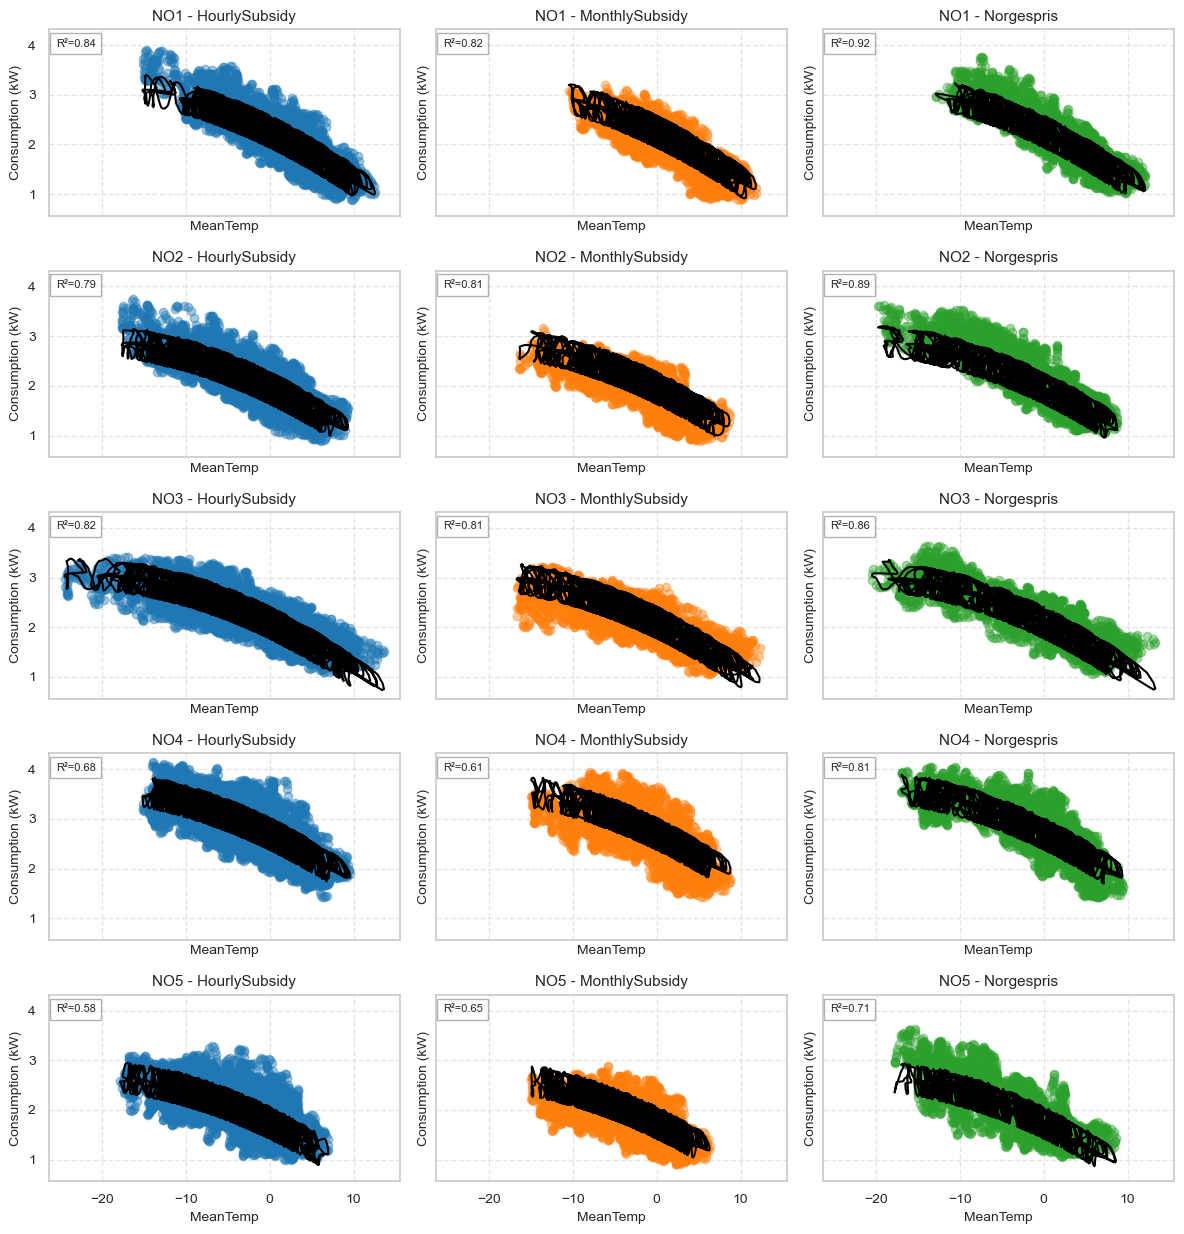

In [19]:

df_model = df_Norge.dropna().copy()
df_model['date'] = pd.to_datetime(df_model['date'])
df_model['MeanTemp_sq'] = df_model['MeanTemp'] ** 2
df_model['is_weekend'] = df_model['date'].dt.weekday >= 5
df_model['weekday'] = df_model['date'].dt.weekday

# --- Combined OLS model for all zones ---
formula = 'Consumption_per_household ~ MeanTemp +MeanTemp_sq + is_weekend + C(weekday)+ C(Zone)+ C(hour) '
best_model = smf.ols(formula, data=df_model).fit()

# Add predicted values
df_model['predicted'] = best_model.predict(df_model)

zones = sorted(hourly_avg['Zone'].unique())
periods = sorted(hourly_avg['Period'].unique())
hour_ticks = [0,5,10,15,20]
period_colors = {periods[0]: 'tab:blue', periods[1]: 'tab:orange', periods[2]: 'tab:green'}

# --- Figure: rows = zones, columns = periods ---
fig, axes = plt.subplots(len(zones), len(periods), figsize=(12, 2.5*len(zones)), sharex=True, sharey=True)
if len(zones) == 1:
    axes = axes[np.newaxis,:]  # Ensure 2D array
if len(periods) == 1:
    axes = axes[:,np.newaxis]

for i, zone in enumerate(zones):
    zone_df = df_model[df_model['Zone']==zone]
    
    for j, period in enumerate(periods):
        ax = axes[i,j]
    
        # Scatter observed points
        obs = df_model[(df_model['Zone']==zone) & (df_model['Period']==period)]
        ax.scatter(obs['MeanTemp'], obs['Consumption_per_household'], alpha=0.4, color=period_colors[period])
        
        # Fit line: use combined model predicted for these points
        ax.plot(obs['MeanTemp'], obs['predicted'], color='black', linestyle='-', label='Fit')
        
        # Compute R² for this zone × period
        if len(obs) > 1:
            R2 = np.corrcoef(obs['Consumption_per_household'], obs['predicted'])[0,1]**2
        else:
            R2 = np.nan
        ax.text(0.02, 0.95, f'R²={R2:.2f}', transform=ax.transAxes,
                ha='left', va='top', fontsize=8,
                bbox=dict(facecolor='white', alpha=0.6, edgecolor='gray'))
        
        ax.set_xlabel('MeanTemp')
        ax.set_ylabel('Consumption (kW)')
        ax.set_title(f'{zone} - {period}')
        ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Use of the Best Model (baseline) and Analysis of residuals

We analyse the residuals obtained from the best-fitting consumption model in order to remove the effects of temperature, hour-of-day, weekday patterns, and zone-specific baseline differences. By working with residuals, the systematic drivers of electricity consumption are filtered out, leaving only unexplained deviations that may be associated with policy changes.

Since the NorgePrice scheme was not implemented in zones NO3 and NO4, these zones are treated as control areas. For each policy period, I compute the average residual in the control zones to capture general shocks or time effects that are unrelated to the policy itself. I then adjust the residuals in the treatment zones (NO1, NO2, NO5) by subtracting the corresponding control-zone average. This step removes common period-specific effects and isolates deviations that are specific to treated zones.

Next, I estimate a regression of the adjusted residuals on policy-period indicators separately for each treatment zone. The coefficients measure how consumption during each policy period differs from the baseline period, after accounting for structural consumption patterns and common trends observed in control zones.

Finally, I express these estimated effects as percentages of baseline consumption and plot them with confidence intervals. The resulting figure shows the policy-induced change in electricity consumption in each treatment zone relative to the baseline period, net of temperature effects and common shocks captured by the control zones.


In [20]:

df_model['residual'] = best_model.resid

# --- Step 2: Compute control-zone residual per period ---
treatment_zones = ['NO1','NO2','NO5']
control_zones   = ['NO3','NO4']

control_resid = df_model[df_model['Zone'].isin(control_zones)].groupby('Period')['residual'].mean().to_dict()

# Adjust residuals for treatment zones by subtracting control mean
def adjust_residual(row):
    if row['Zone'] in treatment_zones:
        return row['residual'] - control_resid.get(row['Period'], 0)
    else:
        return row['residual']

df_model['resid_adjusted'] = df_model.apply(adjust_residual, axis=1)

# --- Step 3: OLS per treatment zone, adjusted residuals vs policy period ---
policy_results = {}

for zone in treatment_zones:
    df_zone = df_model[df_model['Zone'] == zone]
    model = smf.ols('resid_adjusted ~ C(Period)', data=df_zone).fit()
    policy_results[zone] = model
    print(f"\n=== Policy Effect Test for Zone {zone} ===")
    print(model.summary())

# --- Settings ---
treatment_zones = ['NO1','NO2','NO5']
periods = sorted(df['Period'].unique())  # ensure consistent order
zone_colors = ['tab:blue', 'tab:orange', 'tab:green']  # one color per treatment zone
bar_width = 0.2
baseline_period = 'HourlySubsidy'  


######## Plot############ 




=== Policy Effect Test for Zone NO1 ===
                            OLS Regression Results                            
Dep. Variable:         resid_adjusted   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     388.6
Date:                Mon, 09 Mar 2026   Prob (F-statistic):          1.81e-165
Time:                        10:37:09   Log-Likelihood:                 2563.6
No. Observations:               15832   AIC:                            -5121.
Df Residuals:                   15829   BIC:                            -5098.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

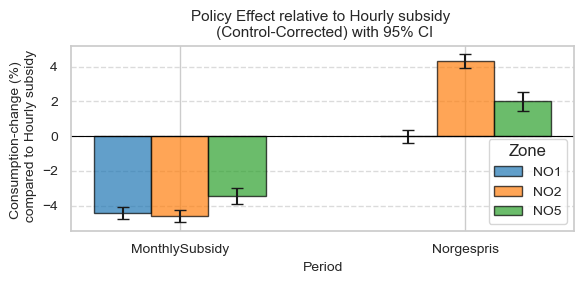

In [21]:
plt.figure(figsize=(6,3))

for i, zone in enumerate(treatment_zones):
    # Extract OLS results for this zone
    model = policy_results[zone]
    
    # Get coefficient estimates and confidence intervals
    coefs = model.params
    conf = model.conf_int()
    
    # Compute effect relative to baseline period
    # 'C(Period)[T.<period>]' corresponds to difference from baseline
    pct_effect = []
    lower_err = []
    upper_err = []
    
    for period in plot_periods:
        term = f'C(Period)[T.{period}]'
        if term in coefs.index:
            effect = coefs[term]
            lower, upper = conf.loc[term]
        else:
            effect = 0.0  # baseline period
            lower, upper = 0.0, 0.0
        
        # Convert to % of baseline consumption
        baseline_mean = df_model[(df_model['Zone']==zone) & (df_model['Period']==baseline_period)]['Consumption_per_household'].mean()
        pct_effect.append(100 * effect / baseline_mean)
        lower_err.append(100 * (effect - lower) / baseline_mean)
        upper_err.append(100 * (upper - effect) / baseline_mean)
    
    # X positions for grouped bars
    x = np.arange(len(plot_periods)) + i * bar_width
    
    # Plot bars with error bars
    plt.bar(x, pct_effect, width=bar_width, color=zone_colors[i], label=zone,
            yerr=[lower_err, upper_err], capsize=4, edgecolor='black', alpha=0.7)

# Formatting
plt.xticks(np.arange(len(plot_periods)) + bar_width, plot_periods)
plt.ylabel('Consumption-change (%) \n compared to Hourly subsidy')
plt.xlabel('Period')
plt.title('Policy Effect relative to Hourly subsidy \n (Control-Corrected) with 95% CI')
plt.axhline(0, color='black', linewidth=0.8)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Zone')
plt.tight_layout()
plt.savefig("PolicyCI.png", dpi=300)
plt.show()